In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import rasterio as rio
import rioxarray as rxr
import matplotlib.pyplot as plt
from glob import glob
import re

## Figure 1 code

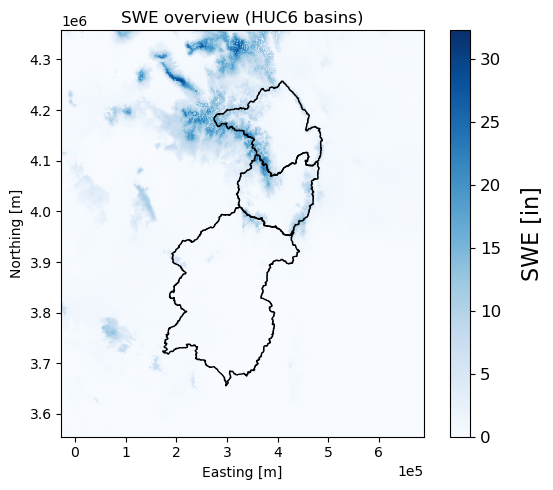

In [76]:
# Read data, reproject to UTM Zone 13N
snodas = rxr.open_rasterio('../data/SNODAS/SNODAS_SWE_20230216.tif').sel(band=1).reset_coords('band', drop=True)
snodas_utm = snodas.rio.reproject('epsg:26913')
huc6 = gpd.read_file('../data/Shapefiles/WBDHU6_RG/WBDHU6_RG.shp').to_crs('epsg:26913')
# Subset HUC6 for visualization, clip SWE data
huc6_viz = huc6.loc[huc6['Name'].isin(['Rio Grande Headwaters','Upper Rio Grande','Rio Grande-Elephant Butte'])]
bounds = huc6_viz.total_bounds
xpad = 200000
ypad = 100000
bounds_padded = [bounds[0]-xpad, bounds[1]-ypad, bounds[2]+xpad, bounds[3]+ypad]
snodas_clip = snodas_utm.where(snodas_utm>=0).rio.clip_box(*bounds_padded) / 1000 * 3.2808 * 12 # convert to inches

# Plot
fig, ax = plt.subplots(figsize=(6,5))
snodas_clip.plot(ax=ax, cmap='Blues')
cbar = ax.collections[-1].colorbar
cbar.set_label('SWE [in]', fontsize=16, labelpad=14)
cbar.ax.tick_params(labelsize=12)
huc6_viz.plot(ax=ax, facecolor='none', edgecolor='k')
ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0)) 
ax.set_xlabel('Easting [m]')
ax.set_ylabel('Northing [m]')
ax.set_title('SWE overview (HUC6 basins)')
plt.tight_layout()
